In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os

# =========================================================
# 新增：用于 t-SNE 特征可视化
# =========================================================
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


In [4]:
# =========================================================
# 1. 基本设置
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

npz_path = "GAF_ReSplitDatasets.npz"

batch_size = 32
num_epochs = 200
learning_rate = 5e-5
weight_decay = 1e-3
patience = 30

save_path = "best_gaf_cnn_vit_mlp_model.pth"

Using device: cuda


In [5]:
# =========================================================
# 2. 读取 npz 数据
# =========================================================

data = np.load(npz_path)

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


# =========================================================
# 3. 标签处理
# =========================================================

if len(y_train.shape) > 1:
    y_train = np.argmax(y_train, axis=1)
    y_val = np.argmax(y_val, axis=1)
    y_test = np.argmax(y_test, axis=1)

y_train = y_train.astype(np.int64)
y_val = y_val.astype(np.int64)
y_test = y_test.astype(np.int64)

num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

X_train shape: (7679, 7, 64, 64)
y_train shape: (7679,)
X_val shape: (961, 7, 64, 64)
y_val shape: (961,)
X_test shape: (960, 7, 64, 64)
y_test shape: (960,)
Number of classes: 3


In [6]:
# =========================================================
# 4. 数据集定义
# =========================================================

class GAFDataset(Dataset):
    def __init__(self, X, y, augment=False, noise_std=0.01, noise_prob=0.7):
        """
        支持以下几种输入格式：
        1. (N, 64, 64, 7)  -> NHWC
        2. (N, 7, 64, 64)  -> NCHW
        3. (N, 64, 7, 64)  -> NHCW

        augment: 是否进行 GAF 图像增强，只建议训练集使用
        noise_std: 高斯噪声标准差，GAF 一般在 [-1, 1]，建议 0.005~0.02
        noise_prob: 每个样本加入噪声的概率
        """
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)

        self.augment = augment
        self.noise_std = noise_std
        self.noise_prob = noise_prob

        print("Original X shape in Dataset:", self.X.shape)
        print("Augmentation:", self.augment)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]

        # 情况 1: x = (64, 64, 7)
        # 转成 (7, 64, 64)
        if x.shape == (64, 64, 7):
            x = np.transpose(x, (2, 0, 1))

        # 情况 2: x = (7, 64, 64)
        elif x.shape == (7, 64, 64):
            pass

        # 情况 3: x = (64, 7, 64)
        # 转成 (7, 64, 64)
        elif x.shape == (64, 7, 64):
            x = np.transpose(x, (1, 0, 2))

        else:
            raise ValueError(f"Unexpected input shape: {x.shape}")

        y = self.y[idx]

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)

        # 只在训练集进行轻微 GAF 噪声增强
        if self.augment:
            x = self.add_light_noise(x)

        return x, y

    def add_light_noise(self, x):
        """
        对 GAF 图像加入轻微高斯噪声
        x shape: (7, 64, 64)
        """
        if torch.rand(1).item() < self.noise_prob:
            noise = self.noise_std * torch.randn_like(x)
            x = x + noise
            x = torch.clamp(x, -1.0, 1.0)

        return x

In [7]:
# =========================================================
# 5. 建立 Dataset 和 DataLoader
# =========================================================

train_dataset = GAFDataset(
    X_train,
    y_train,
    augment=True,
    noise_std=0.02,
    noise_prob=1.0
)

val_dataset = GAFDataset(
    X_val,
    y_val,
    augment=False
)

test_dataset = GAFDataset(
    X_test,
    y_test,
    augment=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

Original X shape in Dataset: (7679, 7, 64, 64)
Augmentation: True
Original X shape in Dataset: (961, 7, 64, 64)
Augmentation: False
Original X shape in Dataset: (960, 7, 64, 64)
Augmentation: False


In [8]:
# =========================================================
# 6. CNN + ViT + MLP 模型
# =========================================================

class CNNFeatureExtractor(nn.Module):
    def __init__(self, in_channels=7, out_channels=128):
        super(CNNFeatureExtractor, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            # 64 x 64 -> 32 x 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            # 32 x 32 -> 16 x 16

            nn.Conv2d(64, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
            # 输出: 128 x 16 x 16
        )

    def forward(self, x):
        return self.cnn(x)


class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=128, embed_dim=128, patch_size=4):
        super(PatchEmbedding, self).__init__()

        self.patch_size = patch_size

        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        """
        x shape: (B, C, H, W)
        after projection: (B, embed_dim, H/patch, W/patch)
        flatten to: (B, num_patches, embed_dim)
        """
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x


class GAF_CNN_ViT_MLP(nn.Module):
    def __init__(
        self,
        in_channels=7,
        num_classes=3,
        cnn_out_channels=128,
        embed_dim=128,
        patch_size=4,
        num_heads=4,
        num_transformer_layers=2,
        mlp_hidden_dim=128,
        dropout=0.5
    ):
        super(GAF_CNN_ViT_MLP, self).__init__()

        self.cnn = CNNFeatureExtractor(
            in_channels=in_channels,
            out_channels=cnn_out_channels
        )

        self.patch_embed = PatchEmbedding(
            in_channels=cnn_out_channels,
            embed_dim=embed_dim,
            patch_size=patch_size
        )

        # CNN 输出是 16 x 16
        # patch_size = 4 后，patch 数量为 4 x 4 = 16
        num_patches = (16 // patch_size) * (16 // patch_size)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(
            torch.zeros(1, num_patches + 1, embed_dim)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_transformer_layers
        )

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden_dim, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

    # =====================================================
    # 新增：用于提取中间层特征
    # =====================================================
    def forward_features(self, x):
        """
        Extract intermediate features for t-SNE visualization.
        input x: (B, 7, 64, 64)
        """

        features = {}

        # 1. CNN features
        cnn_feature = self.cnn(x)
        features["cnn"] = cnn_feature

        # 2. Patch embeddings
        patch_feature = self.patch_embed(cnn_feature)
        features["patch"] = patch_feature

        batch_size = patch_feature.shape[0]

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)

        x = torch.cat((cls_tokens, patch_feature), dim=1)

        x = x + self.pos_embedding

        # 3. Transformer output
        transformer_feature = self.transformer(x)
        features["transformer"] = transformer_feature

        # 4. ViT CLS token features
        cls_feature = transformer_feature[:, 0]
        features["vit_cls"] = cls_feature

        # 5. MLP hidden features
        x_norm = self.mlp_head[0](cls_feature)
        x_fc1 = self.mlp_head[1](x_norm)
        x_gelu = self.mlp_head[2](x_fc1)

        features["mlp_hidden"] = x_gelu

        # 6. Logits
        logits = self.mlp_head(cls_feature)
        features["logits"] = logits

        return features

    def forward(self, x):
        """
        input x: (B, 7, 64, 64)
        """
        x = self.cnn(x)

        x = self.patch_embed(x)

        batch_size = x.shape[0]

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)

        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embedding

        x = self.transformer(x)

        cls_output = x[:, 0]

        out = self.mlp_head(cls_output)

        return out

In [9]:
# =========================================================
# 7. 建立模型
# =========================================================

model = GAF_CNN_ViT_MLP(
    in_channels=7,
    num_classes=num_classes,
    cnn_out_channels=128,
    embed_dim=128,
    patch_size=4,
    num_heads=4,
    num_transformer_layers=2,
    mlp_hidden_dim=128,
    dropout=0.5
).to(device)

print(model)


GAF_CNN_ViT_MLP(
  (cnn): CNNFeatureExtractor(
    (cnn): Sequential(
      (0): Conv2d(7, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU(inplace=True)
    )
  )
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(128, 128, kernel_size=(4, 4), stride=(4, 4))
  )
  (transformer): TransformerEncoder(
    (layers): 

In [10]:
# =========================================================
# 8. 损失函数、优化器和学习率调度器
# =========================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=15
)


# =========================================================
# 9. 训练与验证函数
# =========================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(y_batch.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(y_batch.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)


# =========================================================
# 10. 正式训练
# =========================================================

best_val_loss = np.inf
best_val_acc = 0.0
early_stop_counter = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(
        f"Epoch [{epoch + 1:03d}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.8f}"
    )

    # 以 val_loss 作为保存 best model 的标准
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        early_stop_counter = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "num_classes": num_classes,
                "history": history,
                "best_val_loss": best_val_loss,
                "best_val_acc": best_val_acc
            },
            save_path
        )

        print("Best model saved.")

    else:
        early_stop_counter += 1
        print(f"Early stopping counter: {early_stop_counter}/{patience}")

        # 如果你想启用 early stopping，可以取消下面三行注释
        # if early_stop_counter >= patience:
        #     print("Early stopping triggered.")
        #     break


# =========================================================
# 11. 加载最佳模型，并在测试集上评估
# =========================================================

checkpoint = torch.load(save_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

test_loss, test_acc, y_true, y_pred = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("\n================ Best Validation Result ================")
print("Best Val Loss:", checkpoint["best_val_loss"])
print("Best Val Accuracy:", checkpoint["best_val_acc"])

print("\n================ Test Result ================")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


# =========================================================
# 12. 保存训练历史
# =========================================================

np.savez(
    "training_history_gaf_cnn_vit_mlp.npz",
    train_loss=np.array(history["train_loss"]),
    train_acc=np.array(history["train_acc"]),
    val_loss=np.array(history["val_loss"]),
    val_acc=np.array(history["val_acc"]),
    lr=np.array(history["lr"])
)

print("\nTraining history saved.")
print("Best model saved as:", save_path)


# =========================================================
# 13. t-SNE 特征可视化：提取测试集特征
# =========================================================

def extract_features_for_visualization(model, loader, device):
    model.eval()

    raw_features_list = []
    cnn_features_list = []
    vit_features_list = []
    mlp_features_list = []
    labels_list = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Raw GAF input features
            raw_feature = X_batch.detach().cpu().numpy()
            raw_feature = raw_feature.reshape(raw_feature.shape[0], -1)

            # Intermediate features
            features = model.forward_features(X_batch)

            cnn_feature = features["cnn"].detach().cpu().numpy()
            vit_feature = features["vit_cls"].detach().cpu().numpy()
            mlp_feature = features["mlp_hidden"].detach().cpu().numpy()

            # CNN feature: B × 128 × 16 × 16 -> B × D
            cnn_feature = cnn_feature.reshape(cnn_feature.shape[0], -1)

            raw_features_list.append(raw_feature)
            cnn_features_list.append(cnn_feature)
            vit_features_list.append(vit_feature)
            mlp_features_list.append(mlp_feature)
            labels_list.append(y_batch.detach().cpu().numpy())

    raw_features = np.concatenate(raw_features_list, axis=0)
    cnn_features = np.concatenate(cnn_features_list, axis=0)
    vit_features = np.concatenate(vit_features_list, axis=0)
    mlp_features = np.concatenate(mlp_features_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)

    return raw_features, cnn_features, vit_features, mlp_features, labels


# =========================================================
# 14. t-SNE 降维函数
# =========================================================

def run_tsne(features, random_state=42):
    """
    Standardize features and apply t-SNE.
    """

    features = StandardScaler().fit_transform(features)

    n_samples = features.shape[0]

    # 防止测试样本数量较少时 perplexity 报错
    perplexity = min(30, max(5, n_samples // 3))

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=random_state
    )

    features_2d = tsne.fit_transform(features)

    return features_2d


# =========================================================
# 15. 绘图函数：三分类
# =========================================================

def plot_tsne_three_classes(ax, features_2d, labels, title):
    class_names = {
        0: "Stable cutting",
        1: "Slight chatter",
        2: "Obvious chatter"
    }

    markers = {
        0: "o",
        1: "^",
        2: "s"
    }

    for c in np.unique(labels):
        idx = labels == c

        ax.scatter(
            features_2d[idx, 0],
            features_2d[idx, 1],
            s=25,
            marker=markers.get(c, "o"),
            alpha=0.75,
            label=class_names.get(c, f"Class {c}")
        )

    ax.set_xlabel("Feature 1", fontsize=11)
    ax.set_ylabel("Feature 2", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(False)

Epoch [001/200] Train Loss: 0.8038 | Train Acc: 0.6524 | Val Loss: 0.4258 | Val Acc: 0.8418 | LR: 0.00005000
Best model saved.
Epoch [002/200] Train Loss: 0.4364 | Train Acc: 0.8396 | Val Loss: 0.3098 | Val Acc: 0.8762 | LR: 0.00005000
Best model saved.
Epoch [003/200] Train Loss: 0.3266 | Train Acc: 0.8759 | Val Loss: 0.2896 | Val Acc: 0.8741 | LR: 0.00005000
Best model saved.
Epoch [004/200] Train Loss: 0.2912 | Train Acc: 0.8896 | Val Loss: 0.2935 | Val Acc: 0.8928 | LR: 0.00005000
Early stopping counter: 1/30
Epoch [005/200] Train Loss: 0.2637 | Train Acc: 0.8979 | Val Loss: 0.2689 | Val Acc: 0.8918 | LR: 0.00005000
Best model saved.
Epoch [006/200] Train Loss: 0.2313 | Train Acc: 0.9079 | Val Loss: 0.2845 | Val Acc: 0.8876 | LR: 0.00005000
Early stopping counter: 1/30
Epoch [007/200] Train Loss: 0.2131 | Train Acc: 0.9151 | Val Loss: 0.2100 | Val Acc: 0.9136 | LR: 0.00005000
Best model saved.
Epoch [008/200] Train Loss: 0.2047 | Train Acc: 0.9204 | Val Loss: 0.2315 | Val Acc: 0.91


================ Feature Shapes ================
Raw features: (960, 28672)
CNN features: (960, 32768)
ViT features: (960, 128)
MLP features: (960, 128)
Labels: (960,)


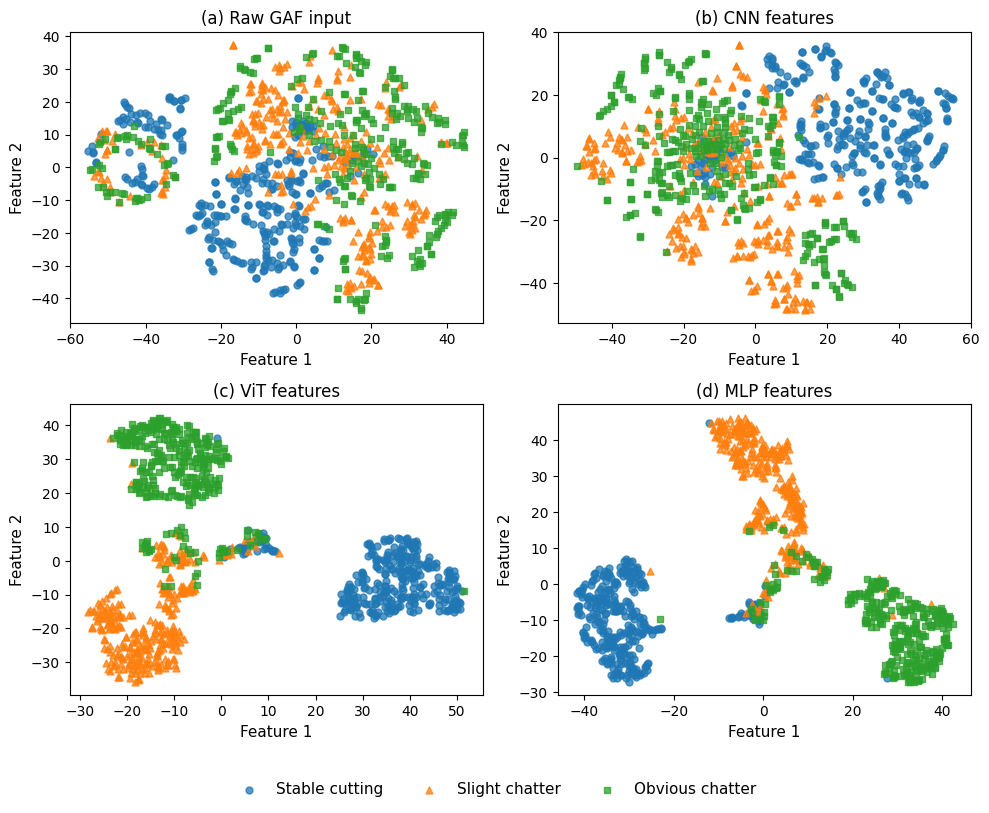

In [12]:
# =========================================================
# 16. 正式生成 t-SNE 特征可视化图
# =========================================================

raw_features, cnn_features, vit_features, mlp_features, labels = extract_features_for_visualization(
    model=model,
    loader=test_loader,
    device=device
)

print("\n================ Feature Shapes ================")
print("Raw features:", raw_features.shape)
print("CNN features:", cnn_features.shape)
print("ViT features:", vit_features.shape)
print("MLP features:", mlp_features.shape)
print("Labels:", labels.shape)

# t-SNE dimensionality reduction
raw_2d = run_tsne(raw_features)
cnn_2d = run_tsne(cnn_features)
vit_2d = run_tsne(vit_features)
mlp_2d = run_tsne(mlp_features)

# Plot t-SNE results
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

plot_tsne_three_classes(axes[0, 0], raw_2d, labels, "(a) Raw GAF input")
plot_tsne_three_classes(axes[0, 1], cnn_2d, labels, "(b) CNN features")
plot_tsne_three_classes(axes[1, 0], vit_2d, labels, "(c) ViT features")
plot_tsne_three_classes(axes[1, 1], mlp_2d, labels, "(d) MLP features")

handles, legend_labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    fontsize=11,
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig(
    "tsne_feature_visualization_testset.png",
    dpi=600,
    bbox_inches="tight"
)

# Compaarsion

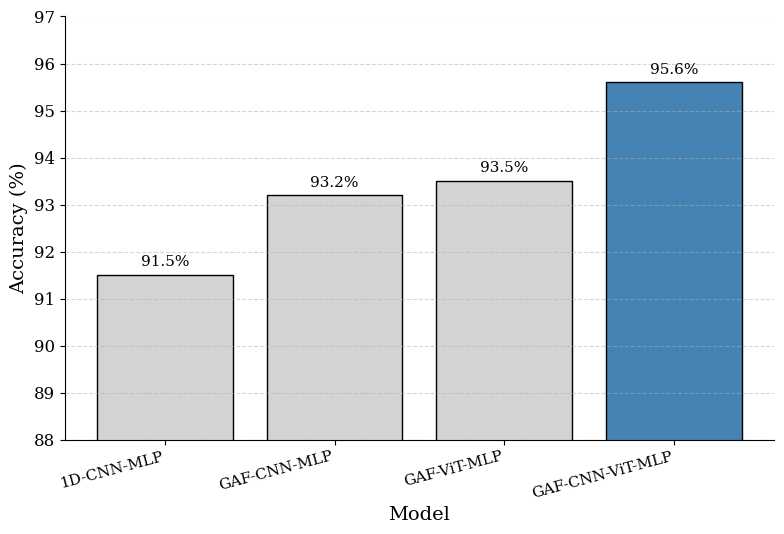

In [14]:
import matplotlib.pyplot as plt
import numpy as np

models = ['1D-CNN-MLP', 'GAF-CNN-MLP', 'GAF-ViT-MLP', 'GAF-CNN-ViT-MLP']
accuracy = [91.5, 93.2, 93.5, 95.6]

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots(figsize=(8, 5.5))

x = np.arange(len(models))
colors = ['lightgray', 'lightgray', 'lightgray', 'steelblue']
bars = ax.bar(x, accuracy, color=colors, edgecolor='black')

ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Model')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylim(88, 97)

for bar, acc in zip(bars, accuracy):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.12, f'{acc:.1f}%',
            ha='center', va='bottom', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

fig.savefig("model_comparison_bar.png", dpi=600, bbox_inches='tight')
fig.savefig("model_comparison_bar.pdf", bbox_inches='tight')
fig.savefig("model_comparison_bar.tiff", dpi=600, bbox_inches='tight')

plt.show()